# Video Game Sales Analysis
Comprehensive Data Science Pipeline: EDA, Visualization, Statistical Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, shapiro, chi2_contingency, zscore
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('vgsales.csv')
print('Original shape:', df.shape)
print('Missing values:')
print(df.isnull().sum())
df = df.dropna(subset=['Year', 'Publisher'])
print('Cleaned shape:', df.shape)
print(df.head())

Original shape: (16598, 11)
Missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Cleaned shape: (16291, 11)
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31

## 2. Distribution Charts

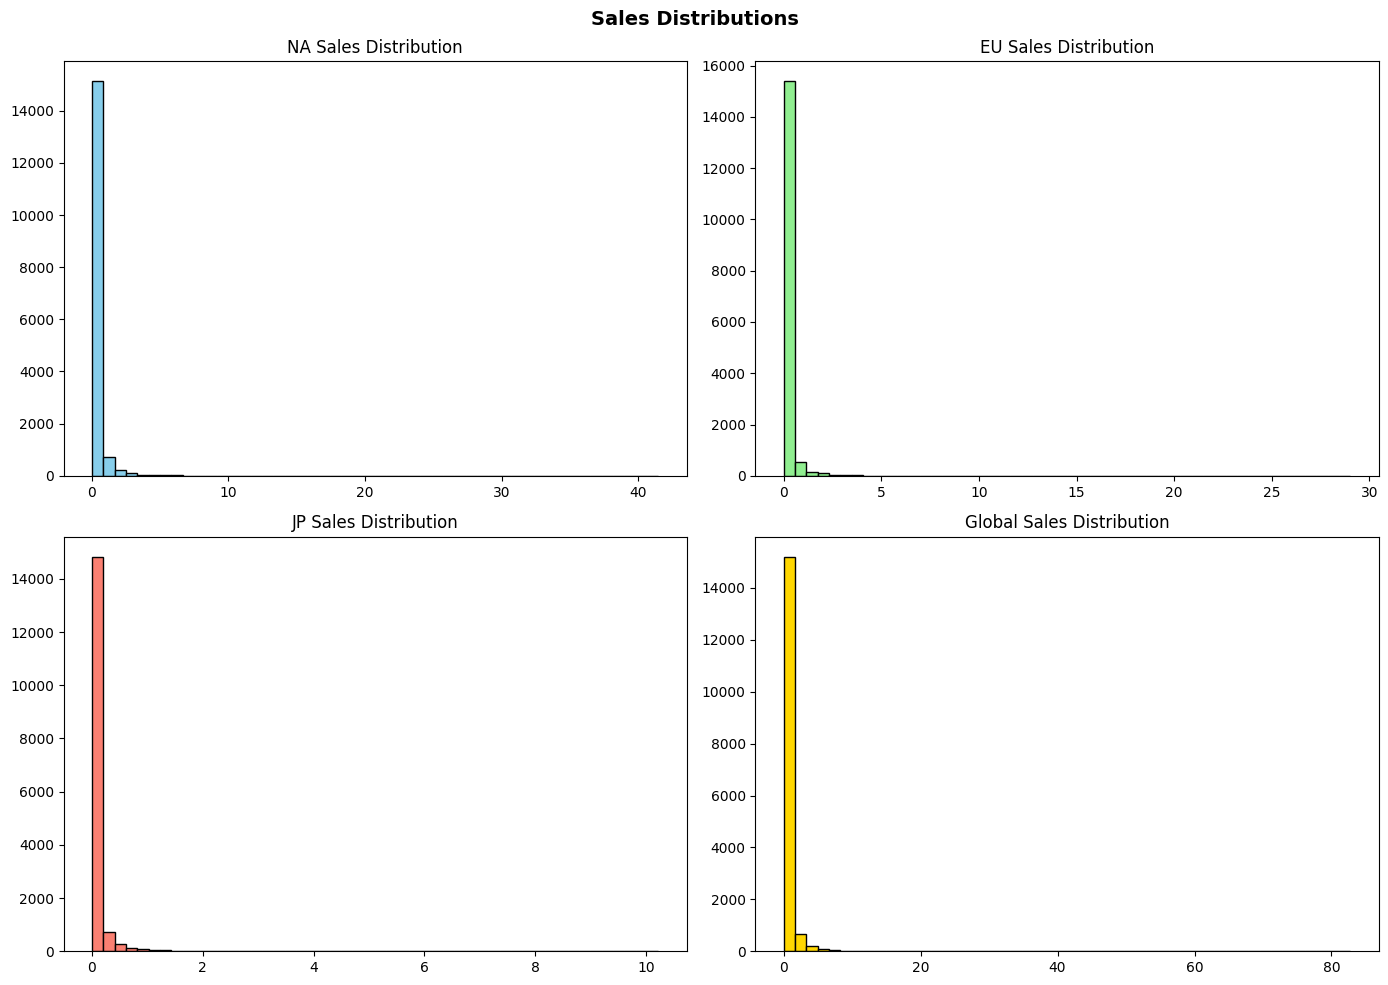

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Distributions', fontsize=14, fontweight='bold')
axes[0, 0].hist(df['NA_Sales'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('NA Sales Distribution')
axes[0, 1].hist(df['EU_Sales'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('EU Sales Distribution')
axes[1, 0].hist(df['JP_Sales'], bins=50, color='salmon', edgecolor='black')
axes[1, 0].set_title('JP Sales Distribution')
axes[1, 1].hist(df['Global_Sales'], bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('Global Sales Distribution')
plt.tight_layout()
plt.show()

## 3. Genre and Platform Analysis

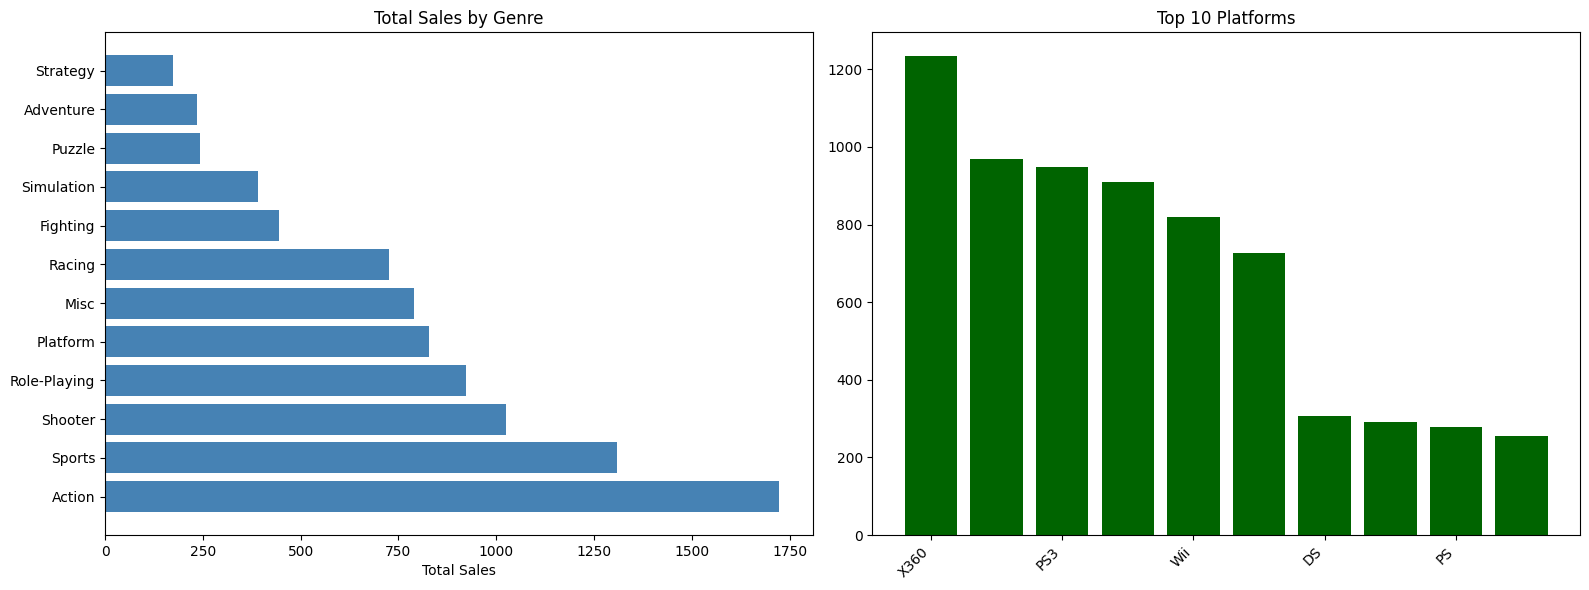

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sales_by_genre = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
axes[0].barh(sales_by_genre.index, sales_by_genre.values, color='steelblue')
axes[0].set_xlabel('Total Sales')
axes[0].set_title('Total Sales by Genre')
sales_by_platform = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
axes[1].bar(range(len(sales_by_platform)), sales_by_platform.values, color='darkgreen')
axes[1].set_xticklabels(sales_by_platform.index, rotation=45, ha='right')
axes[1].set_title('Top 10 Platforms')
plt.tight_layout()
plt.show()

## 4. Temporal Trends

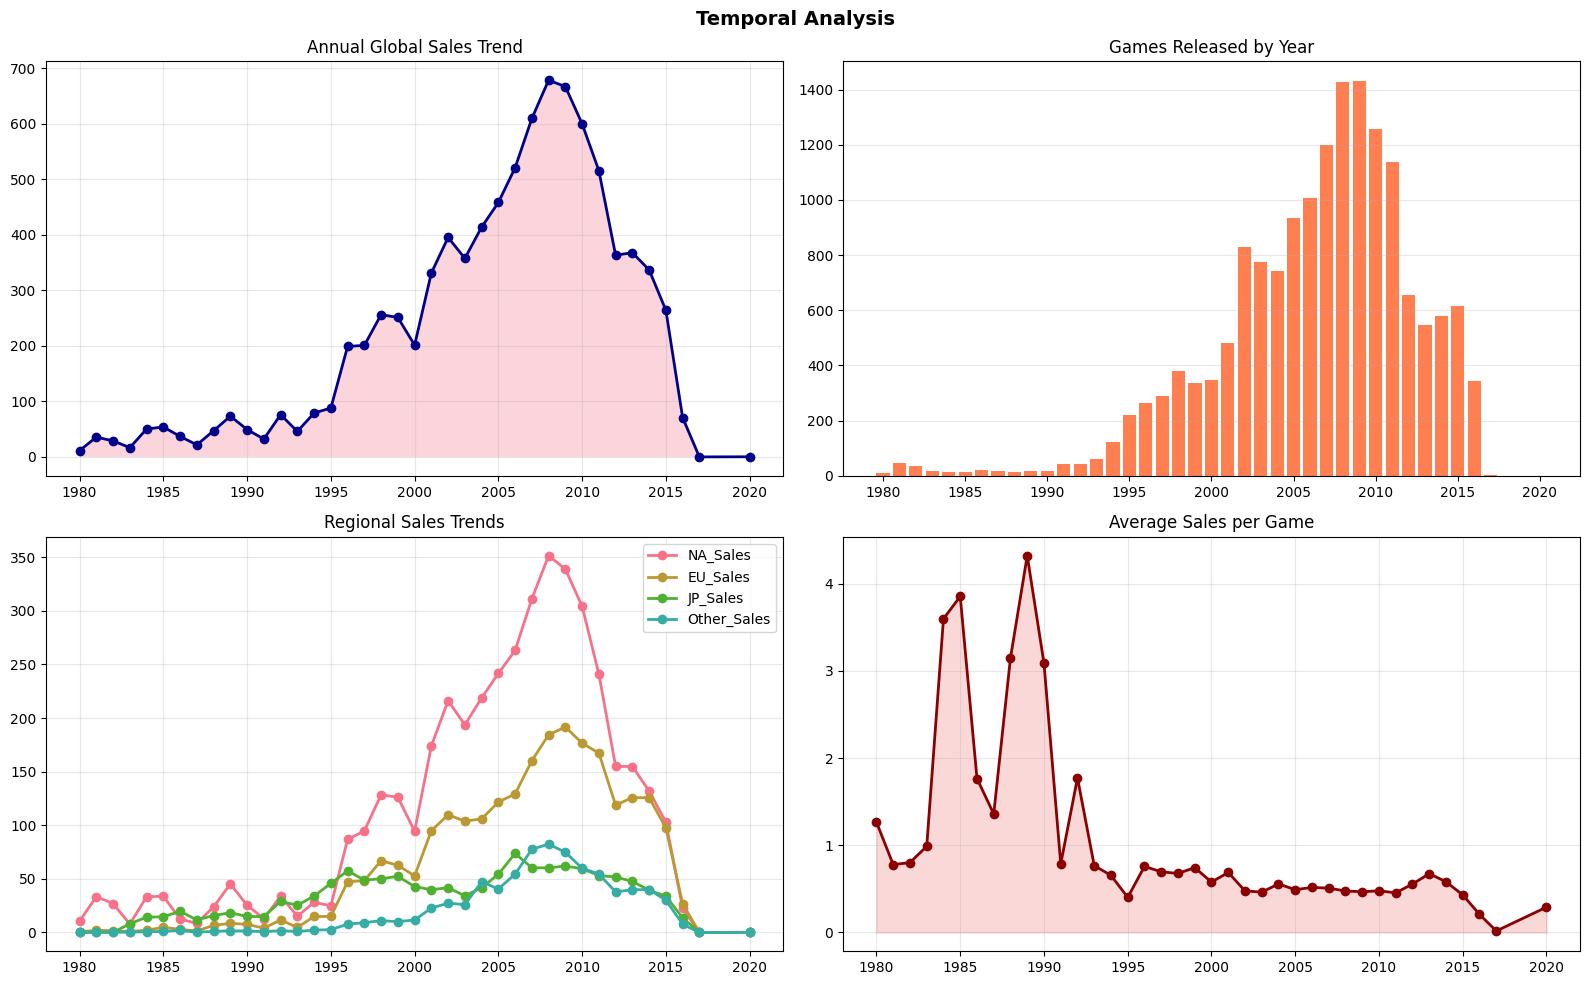

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Analysis', fontsize=14, fontweight='bold')
sales_by_year = df.groupby('Year')['Global_Sales'].sum().sort_index()
axes[0, 0].plot(sales_by_year.index, sales_by_year.values, marker='o', color='darkblue', linewidth=2)
axes[0, 0].fill_between(sales_by_year.index, sales_by_year.values, alpha=0.3)
axes[0, 0].set_title('Annual Global Sales Trend')
axes[0, 0].grid(True, alpha=0.3)
games_by_year = df.groupby('Year').size()
axes[0, 1].bar(games_by_year.index, games_by_year.values, color='coral')
axes[0, 1].set_title('Games Released by Year')
axes[0, 1].grid(axis='y', alpha=0.3)
regional_sales = df.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
for col in regional_sales.columns:
    axes[1, 0].plot(regional_sales.index, regional_sales[col], marker='o', label=col, linewidth=2)
axes[1, 0].set_title('Regional Sales Trends')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
avg_sales = df.groupby('Year')['Global_Sales'].mean()
axes[1, 1].plot(avg_sales.index, avg_sales.values, marker='o', color='darkred', linewidth=2)
axes[1, 1].fill_between(avg_sales.index, avg_sales.values, alpha=0.3, color='lightcoral')
axes[1, 1].set_title('Average Sales per Game')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Seaborn Advanced Charts

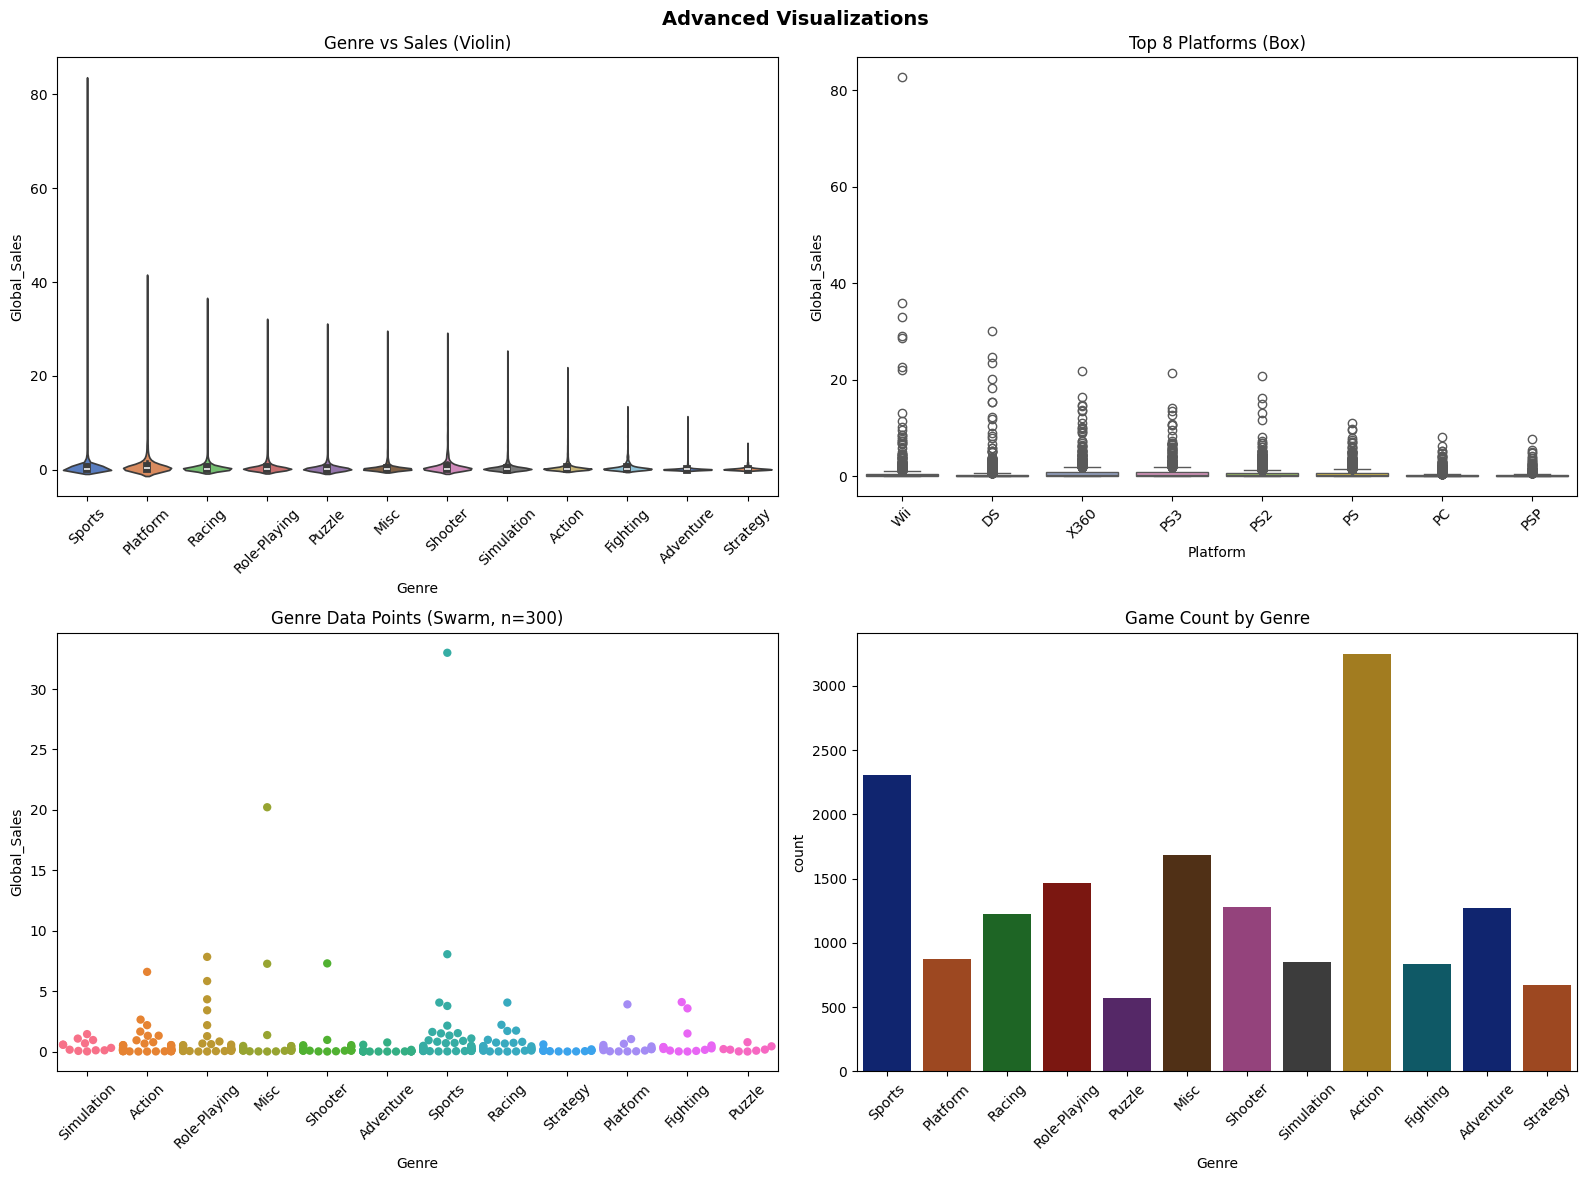

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Visualizations', fontsize=14, fontweight='bold')
sns.violinplot(data=df, x='Genre', y='Global_Sales', ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Genre vs Sales (Violin)')
axes[0, 0].tick_params(axis='x', rotation=45)
top_plat = df['Platform'].value_counts().head(8).index
sns.boxplot(data=df[df['Platform'].isin(top_plat)], x='Platform', y='Global_Sales', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Top 8 Platforms (Box)')
axes[0, 1].tick_params(axis='x', rotation=45)
df_sample = df.sample(n=min(300, len(df)), random_state=42)
sns.swarmplot(data=df_sample, x='Genre', y='Global_Sales', ax=axes[1, 0], palette='husl', size=6)
axes[1, 0].set_title('Genre Data Points (Swarm, n=300)')
axes[1, 0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='Genre', ax=axes[1, 1], palette='dark')
axes[1, 1].set_title('Game Count by Genre')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Heatmap: Genre vs Platform

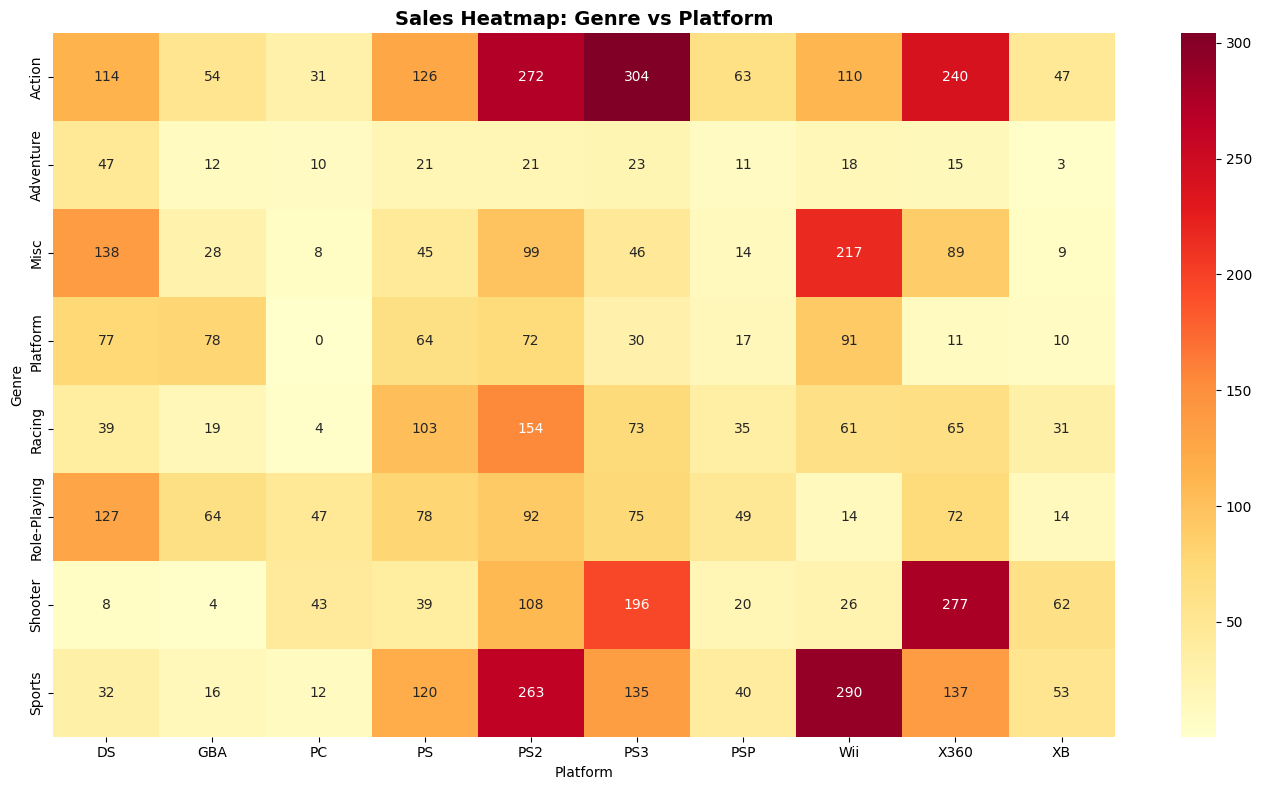

In [7]:
top_genres = df['Genre'].value_counts().head(8).index
top_platforms = df['Platform'].value_counts().head(10).index
pivot_data = df[df['Genre'].isin(top_genres) & df['Platform'].isin(top_platforms)].pivot_table(values='Global_Sales', index='Genre', columns='Platform', aggfunc='sum', fill_value=0)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Sales Heatmap: Genre vs Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [8]:
numeric_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Year']
print('Descriptive Statistics:')
print(df[numeric_cols].describe().round(4))
print('\nSkewness and Kurtosis:')
for col in numeric_cols:
    print(f'{col}: Skewness={df[col].skew():.4f}, Kurtosis={df[col].kurtosis():.4f}')

Descriptive Statistics:
         NA_Sales    EU_Sales    JP_Sales  Other_Sales  Global_Sales  \
count  16291.0000  16291.0000  16291.0000   16291.0000    16291.0000   
mean       0.2656      0.1477      0.0788       0.0484        0.5409   
std        0.8224      0.5093      0.3119       0.1901        1.5673   
min        0.0000      0.0000      0.0000       0.0000        0.0100   
25%        0.0000      0.0000      0.0000       0.0000        0.0600   
50%        0.0800      0.0200      0.0000       0.0100        0.1700   
75%        0.2400      0.1100      0.0400       0.0400        0.4800   
max       41.4900     29.0200     10.2200      10.5700       82.7400   

             Year  
count  16291.0000  
mean    2006.4056  
std        5.8324  
min     1980.0000  
25%     2003.0000  
50%     2007.0000  
75%     2010.0000  
max     2020.0000  

Skewness and Kurtosis:
NA_Sales: Skewness=18.7409, Kurtosis=642.9093
EU_Sales: Skewness=18.7748, Kurtosis=746.4313
JP_Sales: Skewness=11.1242, Kur

## 8. Correlation & Covariance

Correlation Matrix:
              NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales    Year
NA_Sales        1.0000    0.7689    0.4513       0.6345        0.9413 -0.0913
EU_Sales        0.7689    1.0000    0.4364       0.7263        0.9033  0.0061
JP_Sales        0.4513    0.4364    1.0000       0.2906        0.6128 -0.1694
Other_Sales     0.6345    0.7263    0.2906       1.0000        0.7480  0.0411
Global_Sales    0.9413    0.9033    0.6128       0.7480        1.0000 -0.0746
Year           -0.0913    0.0061   -0.1694       0.0411       -0.0746  1.0000


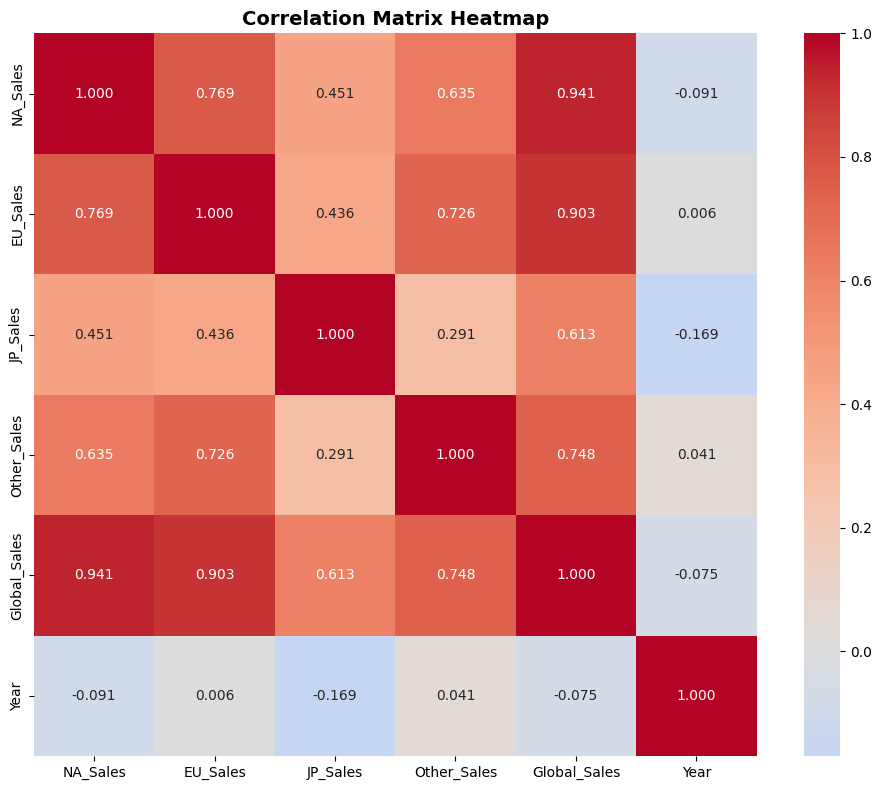

In [9]:
corr_matrix = df[numeric_cols].corr()
print('Correlation Matrix:')
print(corr_matrix.round(4))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Regional Sales Correlation with Global Sales

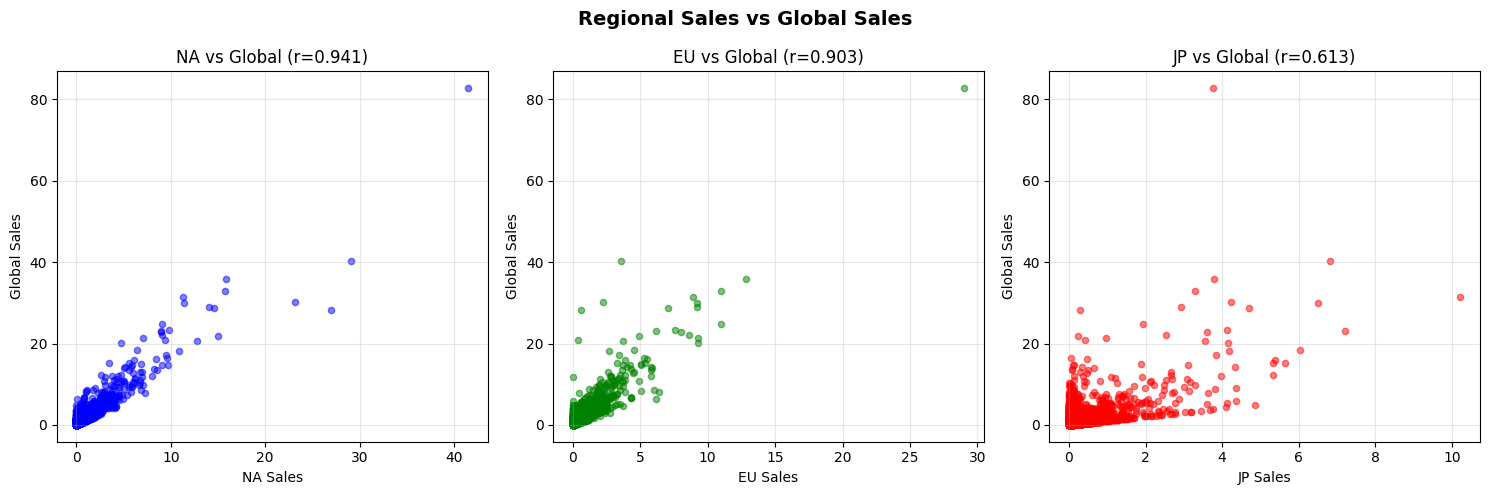

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Regional Sales vs Global Sales', fontsize=14, fontweight='bold')
axes[0].scatter(df['NA_Sales'], df['Global_Sales'], alpha=0.5, s=20, color='blue')
axes[0].set_xlabel('NA Sales')
axes[0].set_ylabel('Global Sales')
axes[0].set_title(f'NA vs Global (r={corr_matrix.loc["NA_Sales", "Global_Sales"]:.3f})')
axes[0].grid(alpha=0.3)
axes[1].scatter(df['EU_Sales'], df['Global_Sales'], alpha=0.5, s=20, color='green')
axes[1].set_xlabel('EU Sales')
axes[1].set_ylabel('Global Sales')
axes[1].set_title(f'EU vs Global (r={corr_matrix.loc["EU_Sales", "Global_Sales"]:.3f})')
axes[1].grid(alpha=0.3)
axes[2].scatter(df['JP_Sales'], df['Global_Sales'], alpha=0.5, s=20, color='red')
axes[2].set_xlabel('JP Sales')
axes[2].set_ylabel('Global Sales')
axes[2].set_title(f'JP vs Global (r={corr_matrix.loc["JP_Sales", "Global_Sales"]:.3f})')
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Outlier Detection

In [11]:
from scipy.stats import zscore
z_scores = np.abs(zscore(df[numeric_cols]))
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print(f'Outliers detected (IQR): {outliers_iqr.sum()}')
print('\nTop 10 Outliers by Global Sales:')
print(df[outliers_iqr].nlargest(10, 'Global_Sales')[['Name', 'Platform', 'Year', 'Genre', 'Global_Sales']])

Outliers detected (IQR): 4616

Top 10 Outliers by Global Sales:
                        Name Platform    Year         Genre  Global_Sales
0                 Wii Sports      Wii  2006.0        Sports         82.74
1          Super Mario Bros.      NES  1985.0      Platform         40.24
2             Mario Kart Wii      Wii  2008.0        Racing         35.82
3          Wii Sports Resort      Wii  2009.0        Sports         33.00
4   Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing         31.37
5                     Tetris       GB  1989.0        Puzzle         30.26
6      New Super Mario Bros.       DS  2006.0      Platform         30.01
7                   Wii Play      Wii  2006.0          Misc         29.02
8  New Super Mario Bros. Wii      Wii  2009.0      Platform         28.62
9                  Duck Hunt      NES  1984.0       Shooter         28.31


## 11. Outlier Box Plots

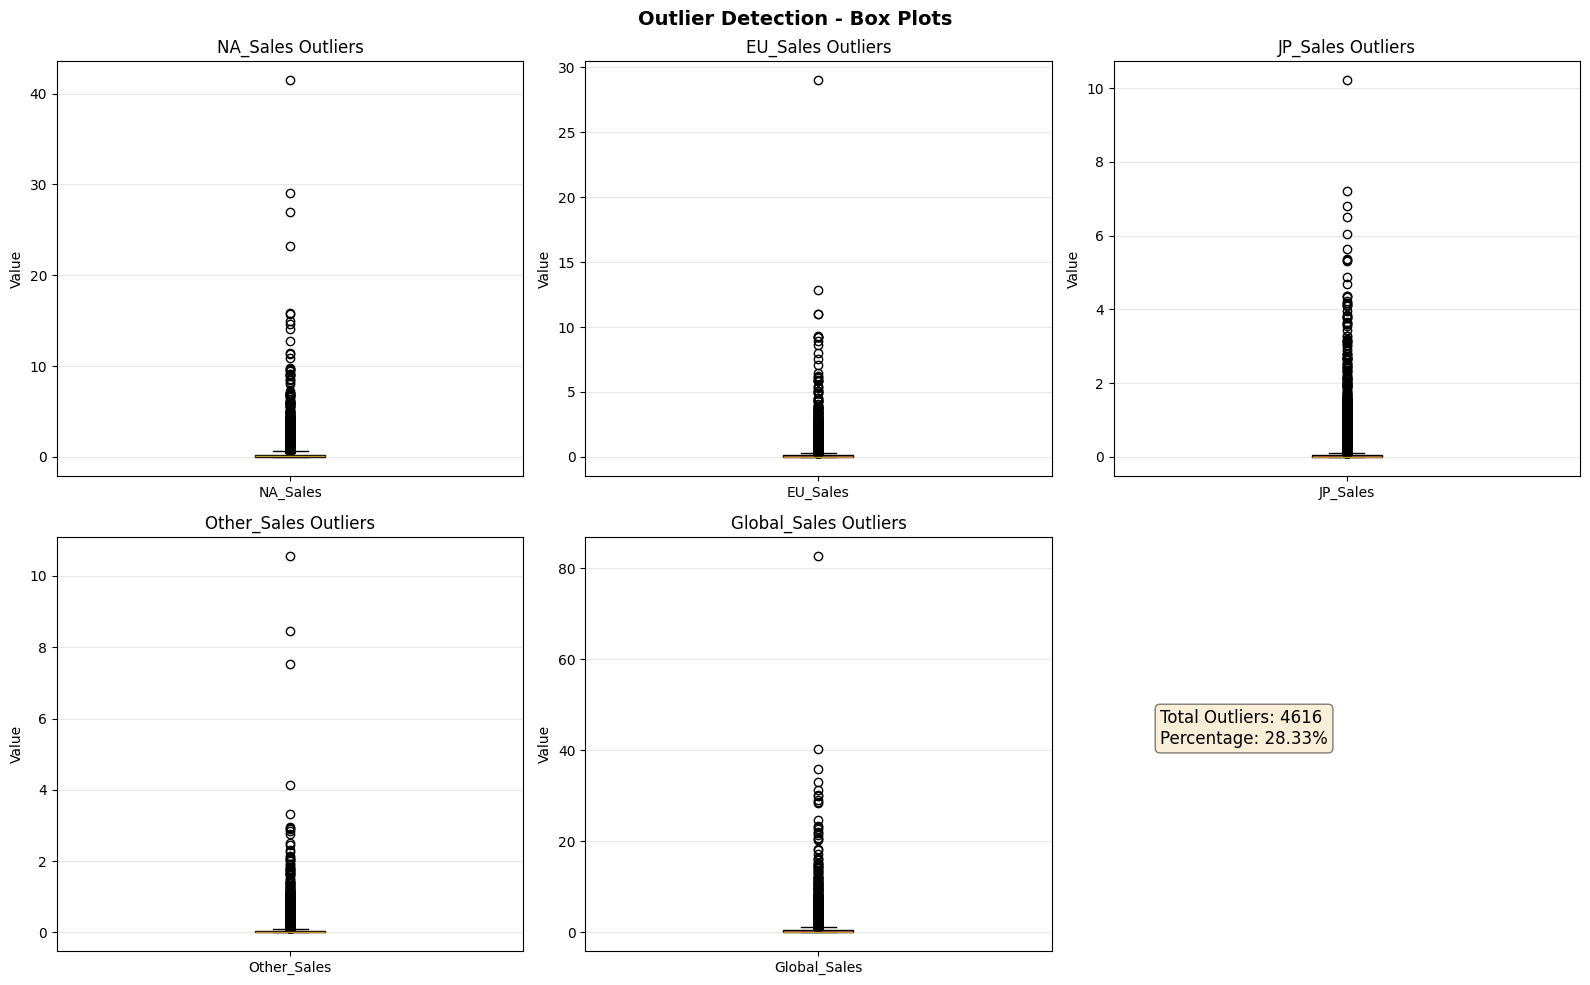

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Outlier Detection - Box Plots', fontsize=14, fontweight='bold')
cols = numeric_cols[:5]
for idx, col in enumerate(cols):
    ax = axes[idx // 3, idx % 3]
    ax.boxplot([df[col]], labels=[col], patch_artist=True)
    ax.set_ylabel('Value')
    ax.set_title(f'{col} Outliers')
    ax.grid(axis='y', alpha=0.3)
axes[1, 2].axis('off')
axes[1, 2].text(0.1, 0.5, f'Total Outliers: {outliers_iqr.sum()}\nPercentage: {(outliers_iqr.sum()/len(df))*100:.2f}%', fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

## 12. Normalization

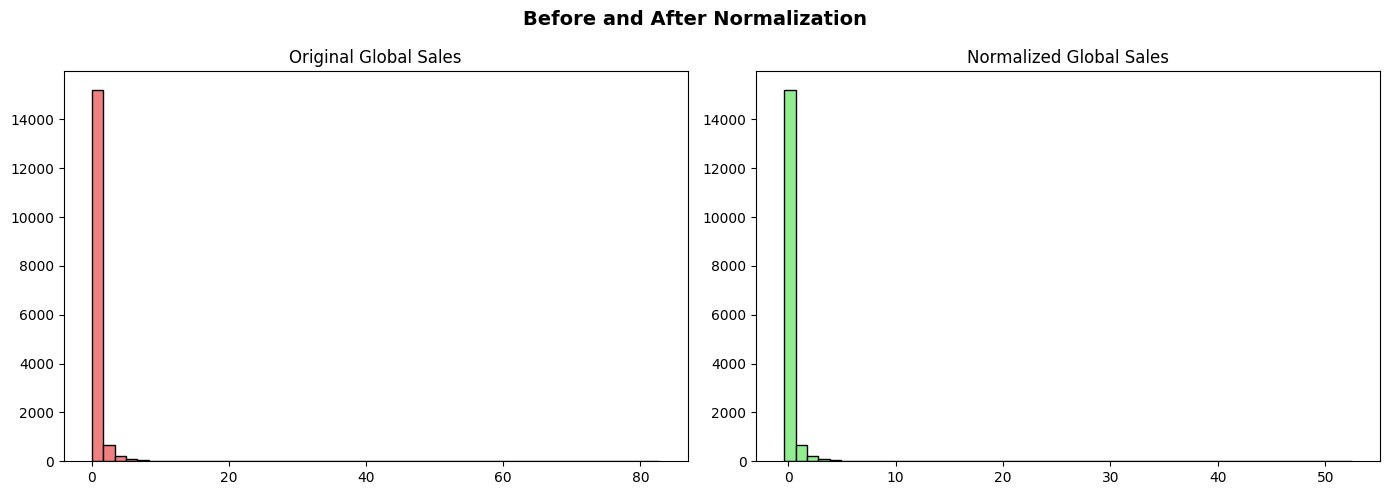

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Before and After Normalization', fontsize=14, fontweight='bold')
axes[0].hist(df['Global_Sales'], bins=50, color='lightcoral', edgecolor='black')
axes[0].set_title('Original Global Sales')
axes[1].hist(df_normalized['Global_Sales'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Normalized Global Sales')
plt.tight_layout()
plt.show()

## 14. T-Test: Nintendo vs Others

In [15]:
from scipy.stats import ttest_ind
nintendo_sales = df[df['Publisher'] == 'Nintendo']['Global_Sales']
other_sales = df[df['Publisher'] != 'Nintendo']['Global_Sales']
t_stat, p_value = ttest_ind(nintendo_sales, other_sales)
print('T-Test: Nintendo vs Other Publishers')
print(f'Nintendo Mean: {nintendo_sales.mean():.4f}')
print(f'Others Mean: {other_sales.mean():.4f}')
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.6f}')
print(f'Conclusion: Significant difference!' if p_value < 0.05 else 'No significant difference')

T-Test: Nintendo vs Other Publishers
Nintendo Mean: 2.5638
Others Mean: 0.4506
T-Statistic: 36.1713
P-Value: 0.000000
Conclusion: Significant difference!


## 15. T-Test Visualization

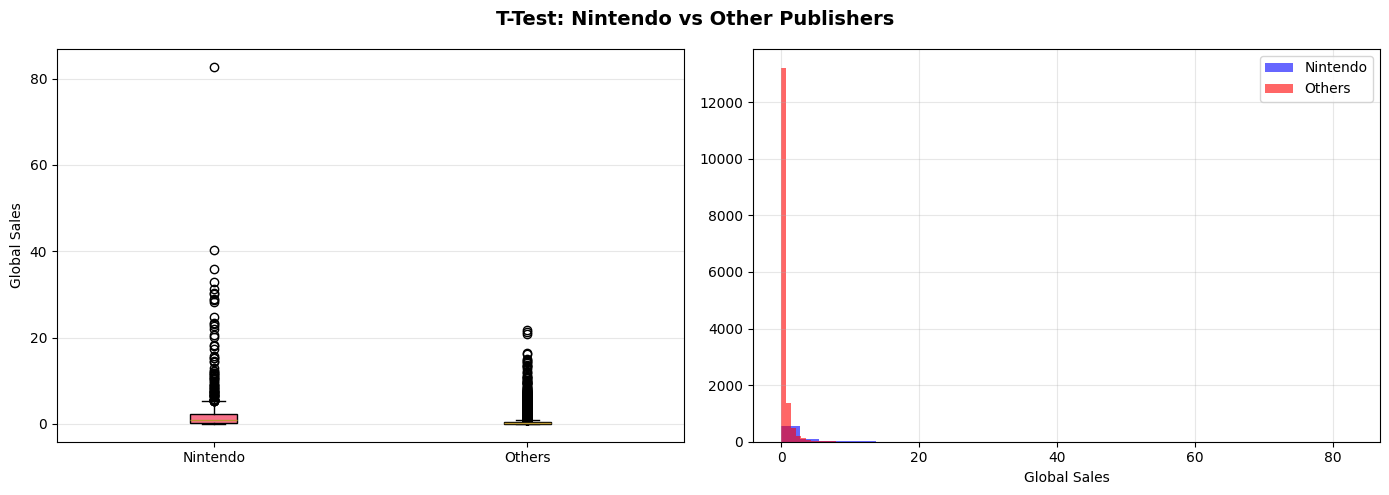

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('T-Test: Nintendo vs Other Publishers', fontsize=14, fontweight='bold')
axes[0].boxplot([nintendo_sales, other_sales], labels=['Nintendo', 'Others'], patch_artist=True)
axes[0].set_ylabel('Global Sales')
axes[0].grid(axis='y', alpha=0.3)
axes[1].hist(nintendo_sales, bins=30, alpha=0.6, label='Nintendo', color='blue')
axes[1].hist(other_sales, bins=30, alpha=0.6, label='Others', color='red')
axes[1].set_xlabel('Global Sales')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16. ANOVA: Genre Effect

In [17]:
from scipy.stats import f_oneway
genre_groups = [group['Global_Sales'].values for name, group in df.groupby('Genre')]
f_stat, p_value_anova = f_oneway(*genre_groups)
print('ANOVA Test: Genre Effect on Global Sales')
print(f'F-Statistic: {f_stat:.4f}')
print(f'P-Value: {p_value_anova:.6f}')
print(f'Conclusion: Significant effect!' if p_value_anova < 0.05 else 'No significant effect')
print('\nMean Sales by Genre:')
print(df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False).round(4))

ANOVA Test: Genre Effect on Global Sales
F-Statistic: 18.1761
P-Value: 0.000000
Conclusion: Significant effect!

Mean Sales by Genre:
Genre
Platform        0.9476
Shooter         0.8005
Role-Playing    0.6285
Racing          0.5933
Sports          0.5682
Fighting        0.5312
Action          0.5299
Misc            0.4685
Simulation      0.4599
Puzzle          0.4249
Strategy        0.2586
Adventure       0.1841
Name: Global_Sales, dtype: float64


## 17. ANOVA Visualization

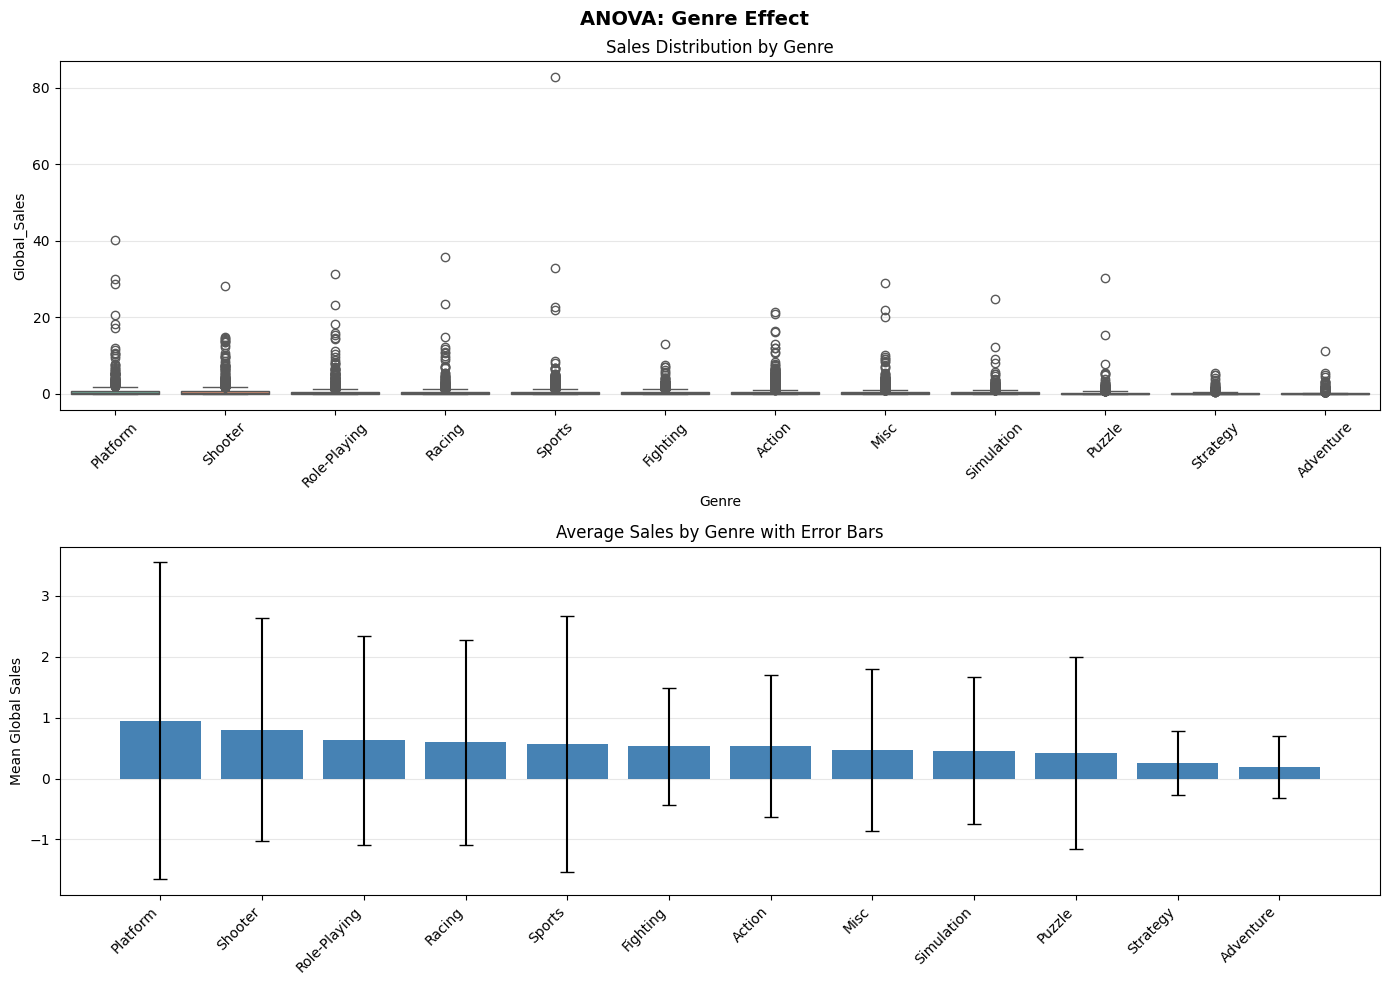

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('ANOVA: Genre Effect', fontsize=14, fontweight='bold')
genre_order = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='Genre', y='Global_Sales', order=genre_order, ax=axes[0], palette='Set2')
axes[0].set_title('Sales Distribution by Genre')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
genre_means = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
genre_std = df.groupby('Genre')['Global_Sales'].std()
axes[1].bar(range(len(genre_means)), genre_means.values, yerr=genre_std[genre_means.index].values, color='steelblue', capsize=5)
axes[1].set_xticks(range(len(genre_means)))
axes[1].set_xticklabels(genre_means.index, rotation=45, ha='right')
axes[1].set_ylabel('Mean Global Sales')
axes[1].set_title('Average Sales by Genre with Error Bars')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Shapiro-Wilk Normality Test

In [19]:
from scipy.stats import shapiro
sample_size = min(5000, len(df))
gs_sample = df['Global_Sales'].sample(n=sample_size, random_state=42)
stat_shapiro, p_value_shapiro = shapiro(gs_sample)
print('Shapiro-Wilk Normality Test')
print(f'Test Statistic: {stat_shapiro:.6f}')
print(f'P-Value: {p_value_shapiro:.6f}')
print(f'Conclusion: Not normally distributed!' if p_value_shapiro < 0.05 else 'Approximately normal')

Shapiro-Wilk Normality Test
Test Statistic: 0.223596
P-Value: 0.000000
Conclusion: Not normally distributed!


## 19. Normality Test Visualization

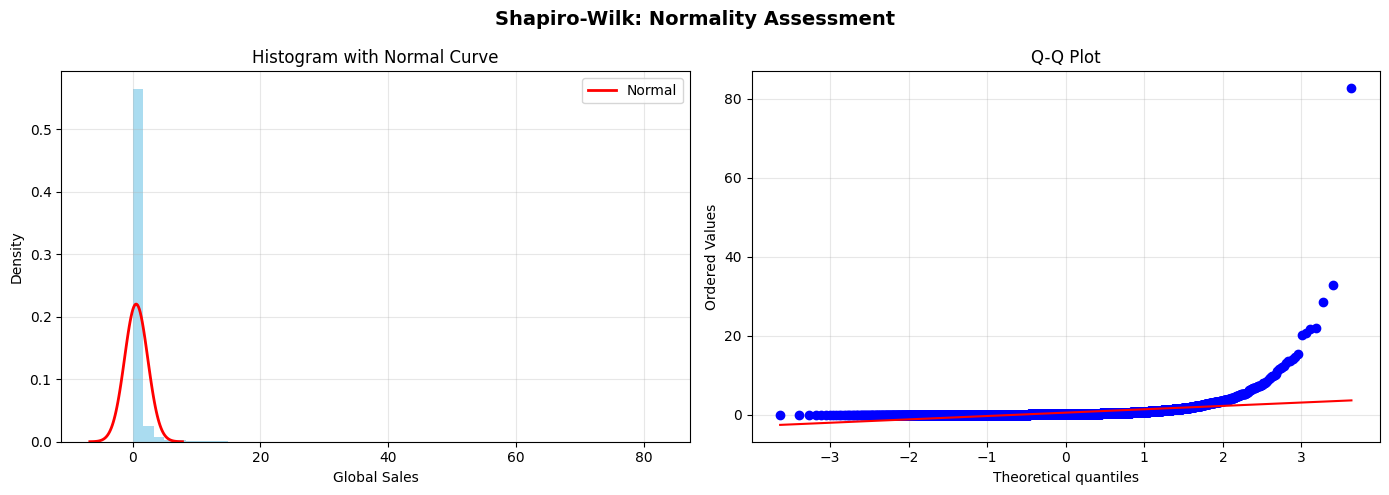

In [20]:
from scipy import stats as sp_stats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shapiro-Wilk: Normality Assessment', fontsize=14, fontweight='bold')
axes[0].hist(gs_sample, bins=50, density=True, alpha=0.7, color='skyblue')
mu, sigma = gs_sample.mean(), gs_sample.std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
axes[0].plot(x, sp_stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
axes[0].set_xlabel('Global Sales')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram with Normal Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)
sp_stats.probplot(gs_sample, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Chi-Squared Test: Independence

In [21]:
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['Genre'], df['Platform'])
chi2, p_value_chi2, dof, expected_freq = chi2_contingency(contingency)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print('Chi-Squared Test: Genre and Platform Independence')
print(f'Chi-Squared Statistic: {chi2:.4f}')
print(f'P-Value: {p_value_chi2:.6f}')
print(f'Cramers V: {cramers_v:.4f}')
print(f'Conclusion: Not independent!' if p_value_chi2 < 0.05 else 'Independent')

Chi-Squared Test: Genre and Platform Independence
Chi-Squared Statistic: 5841.9613
P-Value: 0.000000
Cramers V: 0.1806
Conclusion: Not independent!


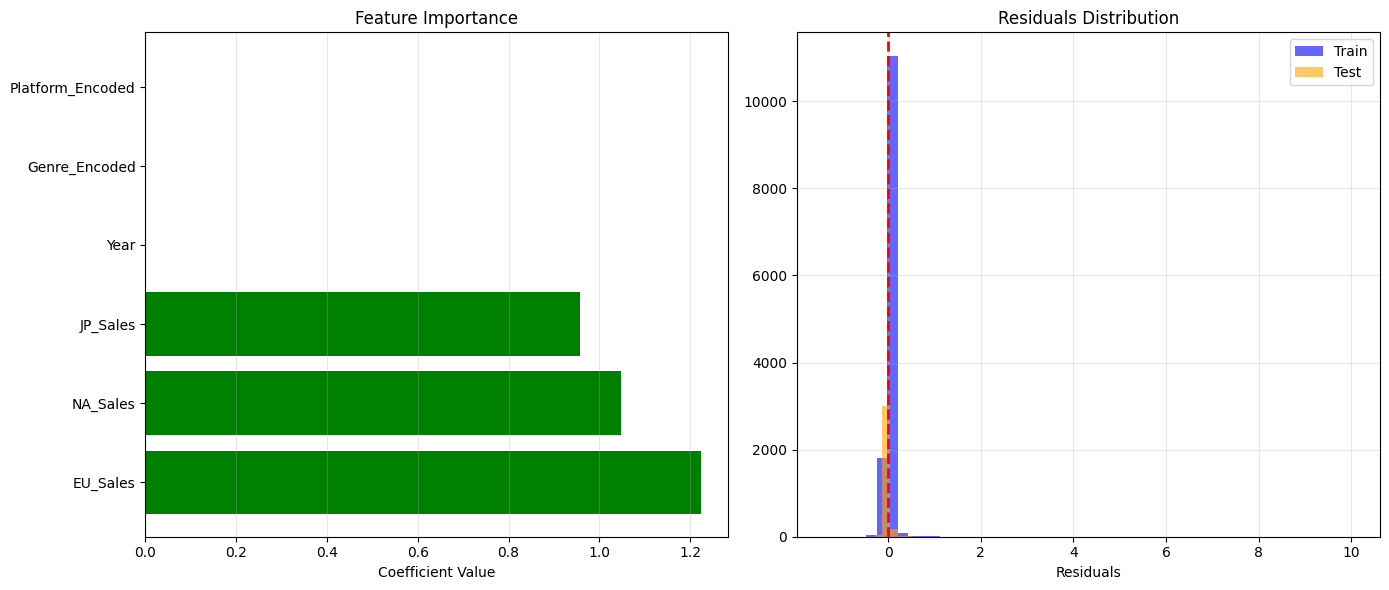


Analysis Complete!


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Feature Importance')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)
axes[1].hist(residuals_train, bins=50, alpha=0.6, label='Train', color='blue')
axes[1].hist(residuals_test, bins=50, alpha=0.6, label='Test', color='orange')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residuals Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('\nAnalysis Complete!')